# Plot Log Scaling From Sampling Checkpoints

This notebook reads `NCC_log_sampling_r` checkpoints from `data/`, aggregates scaling data, and plots `expected_r_min` and `empirical_r_min` versus `N`, `T`, and `\log(1/\epsilon)`.

For 1-st order PF: 

Ising Gate count = $r_{min}(2*N*\kappa +s_0+1)= r_{min}(2*N+ s_0+1)$.

Heisenberg Gate count = $r_{min}(4*N*\kappa + s_0+1)= r_{min}(4*N+ s_0+1)$

In [7]:
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from IPython.display import HTML, display

%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 16})
plt.rcParams['text.usetex'] = True

SAVE_PDF = 1
FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('data')
CHANNEL = 0
TRUNCATION = {'q0': 6, 's0': 6}
BASELINE = {'N': 8, 'T': 2.0, 'epsilon': 0.001, 'trials': 1000, 'repeats': 10}

FIGURE_TAG = 'channel_' if CHANNEL else 'operator_'
RESULT_PREFIX = 'NCC_channel_log_sampling_r' if CHANNEL else 'NCC_log_sampling_r'
RESULT_LABEL = 'channel log' if CHANNEL else 'log'
EPSILON_TARGETS = [0.1, 0.04, 0.02, 0.01, 0.005, 0.0025, 0.001] #, 0.000625]
TARGETS = {
    'N': list(range(4, 10)),
    'T': [0.2, 0.4, 0.8, 1.0, 2.0], # 4.0, 8.0],
    'log_inv_epsilon': [float(math.log(1.0 / eps)) for eps in EPSILON_TARGETS],
}
THEORY_EXPONENTS = {'N': 2 / 3, 'T': 4 / 3, 'log_inv_epsilon': 1.0}

NAME_RE = re.compile(
    rf'^{RESULT_PREFIX}_N(?P<N>[^_]+)_T(?P<T>[^_]+)_eps(?P<epsilon>[^_]+)_trials(?P<trials>\d+)_repeats(?P<repeats>\d+)(?:_q(?P<q0>\d+)_s(?P<s0>\d+))?(?:_(?P<tag>.+))?$'
)


def parse_checkpoint(path):
    match = NAME_RE.match(path.stem)
    if match is None:
        return None
    meta = match.groupdict()
    payload = json.loads(path.read_text())
    sampled = np.array(payload['sampled_r_mins'], dtype=float)
    expected = np.array(payload['expected_r_mins'], dtype=float)
    if sampled.size <= 1:
        sampled_low = sampled_high = float(sampled.mean()) if sampled.size else float('nan')
    else:
        sampled_std = float(np.std(sampled, ddof=1))
        half_width = 1.96 * sampled_std / math.sqrt(sampled.size)
        sampled_low = float(sampled.mean() - half_width)
        sampled_high = float(sampled.mean() + half_width)
    q0_value = None if meta.get('q0') is None else int(meta['q0'])
    s0_value = None if meta.get('s0') is None else int(meta['s0'])
    params = {'q0': q0_value, 's0': s0_value}
    params.update(payload.get('params', {}))
    if params.get('q0') is not None:
        params['q0'] = int(params['q0'])
    if params.get('s0') is not None:
        params['s0'] = int(params['s0'])
    return {
        'path': path,
        'json_path': path,
        'npz_path': path.with_suffix('.npz'),
        'N': int(meta['N']),
        'T': float(meta['T']),
        'epsilon': float(meta['epsilon']),
        'log_inv_epsilon': float(math.log(1.0 / float(meta['epsilon']))),
        'trials': int(meta['trials']),
        'repeats': int(meta['repeats']),
        'q0': params.get('q0'),
        's0': params.get('s0'),
        'sampled_mean': float(sampled.mean()),
        'sampled_low': sampled_low,
        'sampled_high': sampled_high,
        'expected_mean': float(expected.mean()),
        'sampled_values': sampled,
        'expected_values': expected,
        'params': params,
    }


def load_records(data_dir=DATA_DIR):
    records = []
    for path in sorted(data_dir.glob(f'{RESULT_PREFIX}_*.json')):
        record = parse_checkpoint(path)
        if record is None:
            continue
        records.append(record)
    if not records:
        raise FileNotFoundError(f'No {RESULT_LABEL} sampling checkpoints found in {data_dir}')
    return records


def build_axis_series(records, axis, baseline=BASELINE, targets=TARGETS, truncation=TRUNCATION):
    filtered = []
    for record in records:
        if record['trials'] != baseline['trials'] or record['repeats'] != baseline['repeats']:
            continue
        if record['q0'] != truncation['q0'] or record['s0'] != truncation['s0']:
            continue
        if axis != 'N' and record['N'] != baseline['N']:
            continue
        if axis != 'T' and not math.isclose(record['T'], baseline['T'], rel_tol=0.0, abs_tol=1e-12):
            continue
        if axis != 'log_inv_epsilon' and not math.isclose(record['epsilon'], baseline['epsilon'], rel_tol=0.0, abs_tol=1e-12):
            continue
        filtered.append(record)
    ordered = []
    for target in targets[axis]:
        matches = [
            record for record in filtered
            if math.isclose(float(record[axis]), float(target), rel_tol=0.0, abs_tol=1e-12)
        ]
        if not matches:
            continue
        if len(matches) > 1:
            summary = [
                (item['q0'], item['s0'], item['npz_path'].name)
                for item in matches
            ]
            raise ValueError(
                f'Ambiguous records for axis={axis}, target={target}, q0={truncation["q0"]}, s0={truncation["s0"]}: {summary}. '
                'Please keep only one file for this target under the selected q0/s0 configuration.'
            )
        ordered.append(matches[0])
    return ordered


def fit_power_law(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    coeffs = np.polyfit(np.log(x), np.log(y), 1)
    slope = float(coeffs[0])
    prefactor = float(math.exp(coeffs[1]))
    return slope, prefactor


def scaled_reference(x, y0, x0, exponent):
    x = np.array(x, dtype=float)
    return y0 * (x / x0) ** exponent


def format_tick_labels(values):
    labels = []
    for value in np.array(values, dtype=float):
        if math.isclose(value, round(value), abs_tol=1e-12):
            labels.append(str(int(round(value))))
        else:
            labels.append(f'{value:.2f}'.rstrip('0').rstrip('.'))
    return labels


def apply_center_limits(ax, axis, x, y, y_low=None, y_high=None):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    if y_low is None:
        y_low = y
    else:
        y_low = np.array(y_low, dtype=float)
    if y_high is None:
        y_high = y
    else:
        y_high = np.array(y_high, dtype=float)
    if x.size == 1:
        ax.set_xlim(float(x[0] / 1.2), float(x[0] * 1.2))
    else:
        ax.set_xlim(float(np.min(x) / 1.08), float(np.max(x) * 1.08))
    y_min = float(np.min(y_low))
    y_max = float(np.max(y_high))
    if y.size == 1:
        ax.set_ylim(y_min / 1.08, y_max * 1.08)
    else:
        ax.set_ylim(y_min / 1.08, y_max * 1.08)


def plot_missing(ax, title, xlabel):
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel('min gate count', fontsize=18)
    ax.text(0.5, 0.5, 'data not collected', ha='center', va='center', fontsize=18, transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_alpha(0.3)


def plot_expected_panel(ax, records, axis, xlabel, title, theory_exp, invert_x=False):
    if len(records) == 0:
        plot_missing(ax, title, xlabel)
        return None
    x = np.array([item[axis] for item in records], dtype=float)
    y = np.array([item['expected_mean'] for item in records], dtype=float)
    ax.loglog(x, y, 'o', ms=8, color='C0', label='expected $r_{\\min}$')
    slope = None
    if len(records) >= 2:
        slope, prefactor = fit_power_law(x, y)
        theory = scaled_reference(x, y[0], x[0], theory_exp)
        fit = prefactor * x**slope
        ax.loglog(x, theory, '--', lw=2.0, color='C1', label=rf'theory slope ${theory_exp:.3f}$')
        ax.loglog(x, fit, ':', lw=2.2, color='C2', label=rf'fit slope ${slope:.3f}$')
    ax.xaxis.set_major_locator(mticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(x)))
    ax.yaxis.set_major_locator(mticker.FixedLocator(y))
    ax.yaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(y)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel('min gate count', fontsize=18)
    ax.set_title(title, fontsize=20)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=True, fontsize=14)
    return slope


def plot_empirical_panel(ax, records, axis, xlabel, title, theory_exp, invert_x=False):
    if len(records) == 0:
        plot_missing(ax, title, xlabel)
        return None
    x = np.array([item[axis] for item in records], dtype=float)
    y = np.array([item['sampled_mean'] for item in records], dtype=float)
    y_low = np.array([item['sampled_low'] for item in records], dtype=float)
    y_high = np.array([item['sampled_high'] for item in records], dtype=float)
    yerr = np.vstack([
        y - y_low,
        y_high - y,
    ])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.errorbar(x, y, yerr=yerr, fmt='o', ms=8, capsize=5, color='C0', label='empirical $r_{\\min}$')
    slope = None
    if len(records) >= 2:
        slope, prefactor = fit_power_law(x, y)
        theory = scaled_reference(x, y[0], x[0], theory_exp)
        fit = prefactor * x**slope
        ax.loglog(x, theory, '--', lw=2.0, color='C1', label=rf'theory slope ${theory_exp:.3f}$')
        ax.loglog(x, fit, ':', lw=2.2, color='C2', label=rf'fit slope ${slope:.3f}$')
    apply_center_limits(ax, axis, x, y, y_low=y_low, y_high=y_high)
    ax.xaxis.set_major_locator(mticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(x)))
    ax.yaxis.set_major_locator(mticker.FixedLocator(y))
    ax.yaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(y)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    if axis == 'log_inv_epsilon':
        ax.tick_params(axis='x', labelrotation=20)
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel('min gate count', fontsize=18)
    ax.set_title(title, fontsize=20)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=True, fontsize=14)
    return slope


records = load_records()
series_by_axis = {
    'N': build_axis_series(records, 'N'),
    'T': build_axis_series(records, 'T'),
    'log_inv_epsilon': build_axis_series(records, 'log_inv_epsilon'),
}

print('baseline:', BASELINE)
print('truncation:', TRUNCATION)
for axis, series in series_by_axis.items():
    print(axis, [(item['N'], item['T'], item['epsilon'], item['q0'], item['s0'], item['sampled_mean'], item['expected_mean']) for item in series])


baseline: {'N': 8, 'T': 2.0, 'epsilon': 0.001, 'trials': 1000, 'repeats': 10}
truncation: {'q0': 6, 's0': 6}
N [(4, 2.0, 0.001, 6, 6, 389.5, 24.0), (5, 2.0, 0.001, 6, 6, 405.5, 20.0), (6, 2.0, 0.001, 6, 6, 542.1, 24.0), (7, 2.0, 0.001, 6, 6, 552.2, 21.0), (8, 2.0, 0.001, 6, 6, 681.7, 28.0)]
T [(8, 0.2, 0.001, 6, 6, 34.0, 3.0), (8, 0.4, 0.001, 6, 6, 85.4, 5.0), (8, 0.8, 0.001, 6, 6, 212.0, 11.0), (8, 1.0, 0.001, 6, 6, 285.9, 13.0), (8, 2.0, 0.001, 6, 6, 681.7, 28.0)]
log_inv_epsilon [(8, 2.0, 0.1, 6, 6, 54.8, 14.0), (8, 2.0, 0.04, 6, 6, 79.6, 16.0), (8, 2.0, 0.02, 6, 6, 118.5, 18.0), (8, 2.0, 0.01, 6, 6, 179.3, 19.0), (8, 2.0, 0.005, 6, 6, 278.6, 22.0), (8, 2.0, 0.0025, 6, 6, 408.1, 24.0), (8, 2.0, 0.001, 6, 6, 681.7, 28.0)]


q0=6, s0=6


{'N': 0.1743325109822698,
 'T': 0.9809681413502307,
 'log_inv_epsilon': 0.618409780969409}

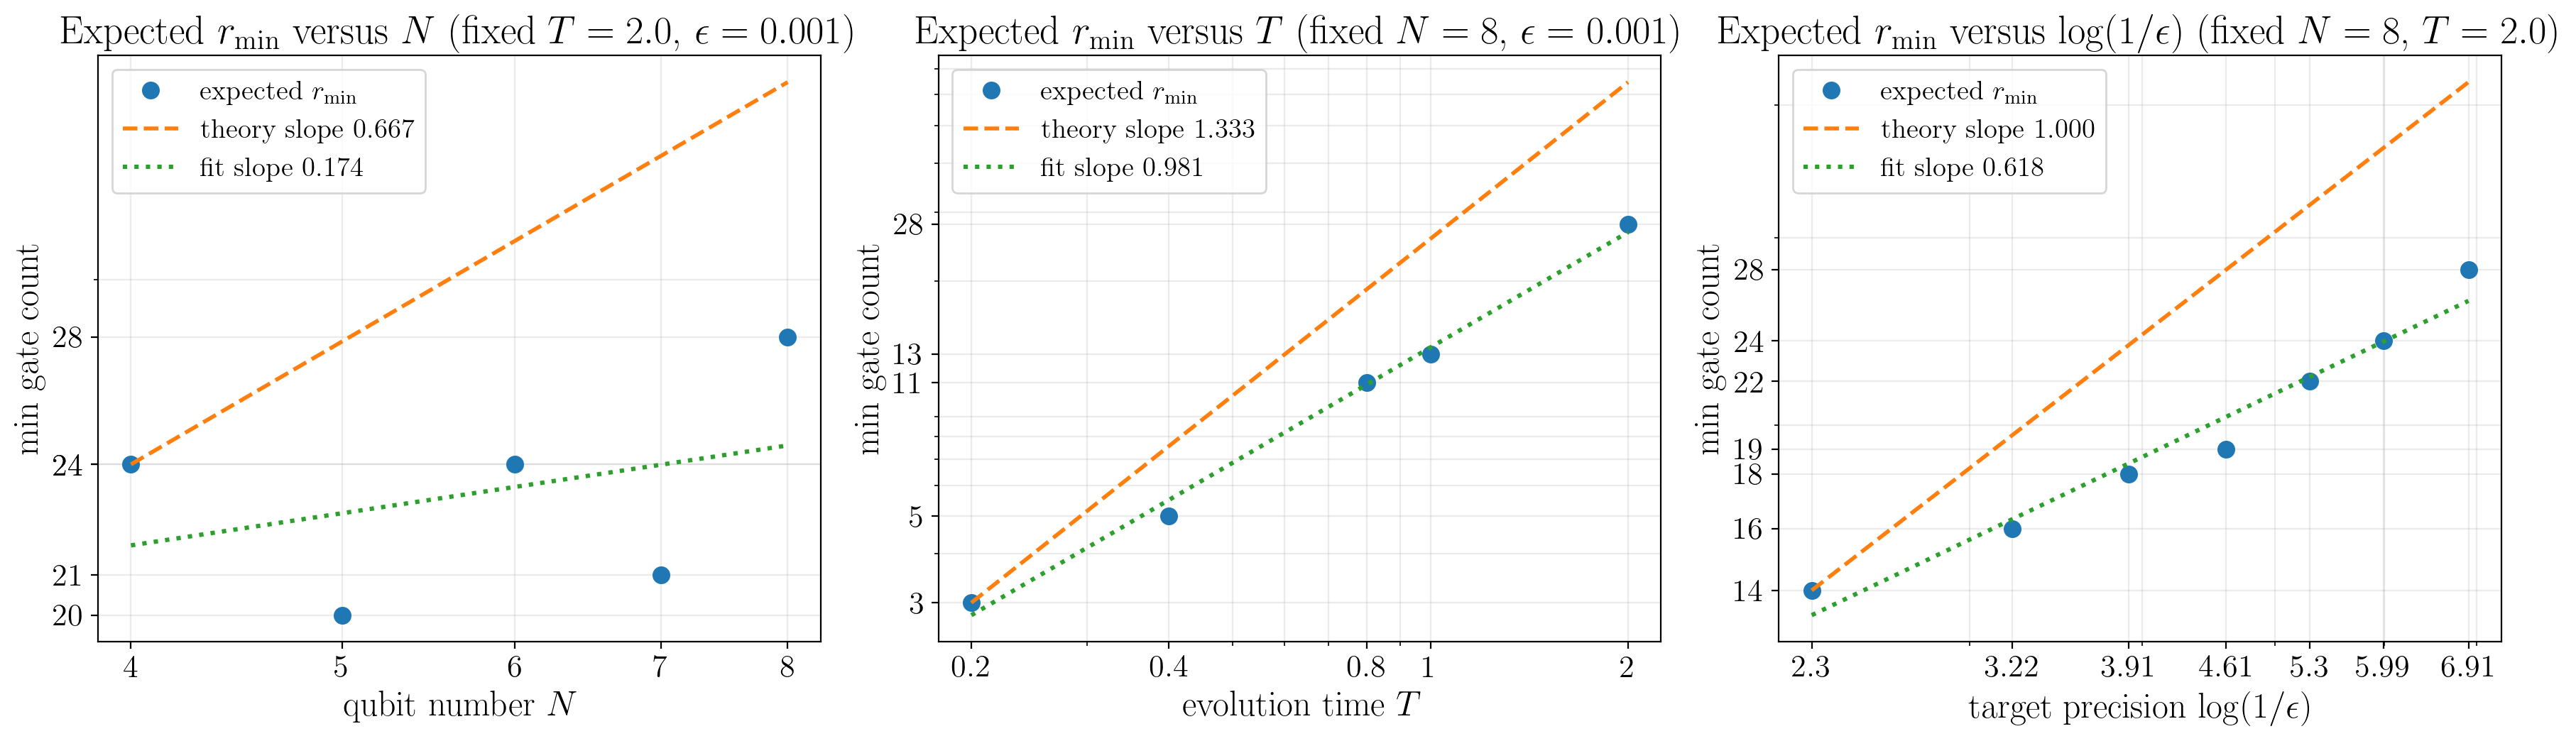

In [8]:
# display(HTML("<div style='color:#c62828; font-weight:600;'>The third-panel scaling is inverted because improving target precision also increases the truncation order $s_0$ and $q_0$.</div>"))
print(f"q0={TRUNCATION['q0']}, s0={TRUNCATION['s0']}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
slopes_expected = {}
slopes_expected['N'] = plot_expected_panel(
    axes[0],
    series_by_axis['N'],
    'N',
    r'qubit number $N$',
    rf'Expected $r_{{\min}}$ versus $N$ (fixed $T={BASELINE["T"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['N'],
)
slopes_expected['T'] = plot_expected_panel(
    axes[1],
    series_by_axis['T'],
    'T',
    r'evolution time $T$',
    rf'Expected $r_{{\min}}$ versus $T$ (fixed $N={BASELINE["N"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['T'],
)
slopes_expected['log_inv_epsilon'] = plot_expected_panel(
    axes[2],
    series_by_axis['log_inv_epsilon'],
    'log_inv_epsilon',
    r'target precision $\log(1/\epsilon)$',
    rf'Expected $r_{{\min}}$ versus $\log(1/\epsilon)$ (fixed $N={BASELINE["N"]}$, $T={BASELINE["T"]}$)',
    THEORY_EXPONENTS['log_inv_epsilon'],
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / f'scaling_{FIGURE_TAG}log_expected.pdf', bbox_inches='tight')
slopes_expected


q0=6, s0=6


{'N': 0.8163961167437592,
 'T': 1.3050776033626719,
 'log_inv_epsilon': 2.3240125551772586}

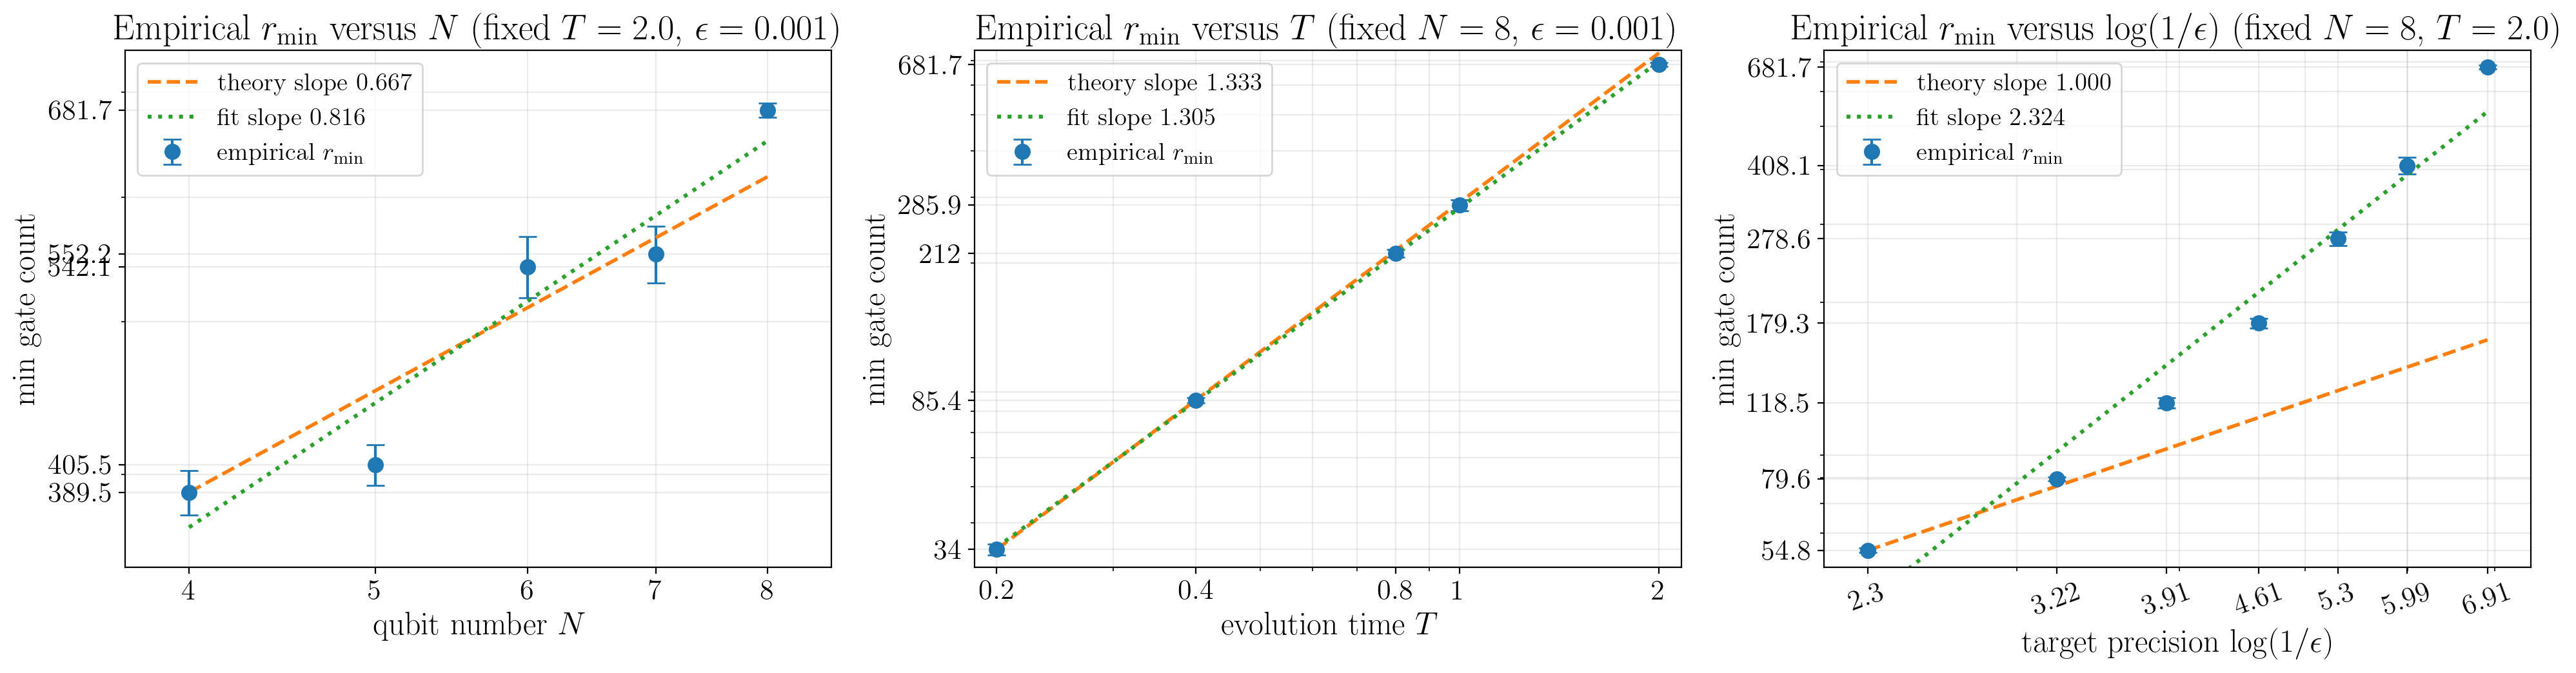

In [9]:
print(f"q0={TRUNCATION['q0']}, s0={TRUNCATION['s0']}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
slopes_empirical = {}
slopes_empirical['N'] = plot_empirical_panel(
    axes[0],
    series_by_axis['N'],
    'N',
    r'qubit number $N$',
    rf'Empirical $r_{{\min}}$ versus $N$ (fixed $T={BASELINE["T"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['N'],
)
slopes_empirical['T'] = plot_empirical_panel(
    axes[1],
    series_by_axis['T'],
    'T',
    r'evolution time $T$',
    rf'Empirical $r_{{\min}}$ versus $T$ (fixed $N={BASELINE["N"]}$, $\epsilon={BASELINE["epsilon"]}$)',
    THEORY_EXPONENTS['T'],
)
slopes_empirical['log_inv_epsilon'] = plot_empirical_panel(
    axes[2],
    series_by_axis['log_inv_epsilon'],
    'log_inv_epsilon',
    r'target precision $\log(1/\epsilon)$',
    rf'Empirical $r_{{\min}}$ versus $\log(1/\epsilon)$ (fixed $N={BASELINE["N"]}$, $T={BASELINE["T"]}$)',
    THEORY_EXPONENTS['log_inv_epsilon'],
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / f'scaling_{FIGURE_TAG}log_empirical.pdf', bbox_inches='tight')
slopes_empirical